# Imports

In [1]:
import numpy as np
import csv
import matplotlib.pyplot as plt
# set rng
rng = np.random.default_rng(42)

In [3]:
incomes = []
with open('../Income-Data.csv', encoding='utf-8') as file:
    reader = csv.DictReader(file, delimiter=';')
    for row in reader:
        incomes.append(int(row['income-range']))

print(f'Sanity check, number of incomes: {len(incomes)}\n')
print(incomes)
print(np.sort(np.unique(incomes)))

Sanity check, number of incomes: 11

[80000, 45000, 50000, 60000, 70000, 45000, 40000, 100000, 30000, 90000, 50000]
[ 30000  40000  45000  50000  60000  70000  80000  90000 100000]


In [4]:
# try all thresholds
thresholds = [20000, 30000, 40000, 45000, 50000, 60000, 70000, 80000, 90000, 100000]
sensitivity = 1
epsilons = [0.1, 0.5, 1.0, 5.0]

people_above_thresholds = {}
for X in thresholds:
    count = sum(1 for x in incomes if x > X)
    people_above_thresholds[X] = count
print(f'People above thresholds: {people_above_thresholds}')
# makes sense since 45k and 50k are duplicated

People above thresholds: {20000: 11, 30000: 10, 40000: 9, 45000: 7, 50000: 5, 60000: 4, 70000: 3, 80000: 2, 90000: 1, 100000: 0}


In [5]:
n_repeats = 1000            

def compute_noisy_counts(people_above_thresholds, thresholds, epsilons, sensitivity, n_repeats):
    """
    Compute noisy counts for each threshold and epsilon combination.
    """
    results = {}
    for X in thresholds:
        count = people_above_thresholds[X]
        rng = np.random.default_rng(42)
        for eps in epsilons:
            b = sensitivity / eps
            noise = rng.laplace(0, b, size=n_repeats)
            noisy_counts = count + noise
            if eps not in results:
                results[eps] = {}
            results[eps][X] = []
            results[eps][X].append(noisy_counts)
    return results
           
results = compute_noisy_counts(people_above_thresholds, thresholds, epsilons, sensitivity, 1000)

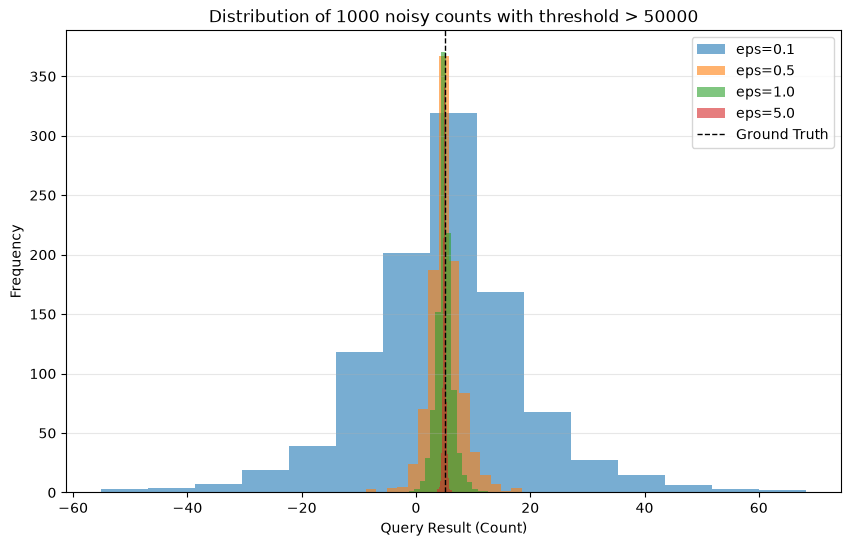

In [6]:
threshold_to_plot = 50000
plt.figure(figsize=(10, 6))

for eps in epsilons:
    plt.hist(results[eps][threshold_to_plot], bins=15, alpha=0.6, label=f'eps={eps}')

# Show ground truth
plt.axvline(people_above_thresholds[threshold_to_plot], color='black', linestyle='dashed', linewidth=1, label='Ground Truth')

plt.title(f'Distribution of {n_repeats} noisy counts with threshold > {threshold_to_plot}')
plt.xlabel('Query Result (Count)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Finding a nice epsilon
- work is inspired by: https://openmined.org/blog/choosing-epsilon/

In [7]:
def calculate_upper_bound_posterior(total_cnt, epsilon, bounded_sensitivity=1.0, unbounded_sensitivity=1.0):
    """    
    Parameters:
    - total_cnt: Total number of data points
    - epsilon: privacy parameter
    - bounded_/unbounded_sensitivity: The bounded/ unbounded sensitivity of the query (default is 1 for count queries)
    
    Returns:
    - upper_bound: The upper bound of posterior.
    """
    # bounded and unbounded sensitivity are the same for count queries.
    # Formula = 1/ (1+(cnt-1) * exp(-epsilon * bounded / unvounded snesitivities))
    return 1.0 / (1.0 + (total_cnt - 1) * np.exp(-epsilon * bounded_sensitivity / unbounded_sensitivity))

In [8]:
def calculate_tighter_upper_bound_posterior(total_cnt, cnt_above_threshold, epsilon, sensitivity=1.0):
    """    
    Parameters:
    - total_cnt: Total number of data points
    - cnt_above_threshold: Count of data points above the threshold
    - epsilon: privacy parameter
    - sensitivity: The sensitivity of the query (default is 1 for count queries)
    
    Returns:
    - upper_bound: The upper bound of posterior.
    """
    # if everyone is above or below the threshold then the posterior is just 1/n
    if cnt_above_threshold == 0 or cnt_above_threshold == total_cnt:
        return 1.0 / total_cnt
    
    # in the orginal example we perform N^2 comparisons of the possible datasets with the query and select the max. But for a count query it's much simpler. Regardless of who we pick to remove there are only 2 groups of universes - the ones where we remove a person above the threshold and the ones where we remove a person below the threshold. So we can just compute the posterior for each of these 2 groups and take the max.
    
    # Formula: 1/ denominator_posterior with denominator_posterior += exp(-epsilon * L1_norm / sensitivity) for all L1 norms computed in the earlier step. For our cases the L1 norms are either 0 or 1.
    
    # case 1: remove a person above the threshold. k times the L1=0 so we get exp(0) = 1, N-k times we do the formula
    denominator_posterior_case_one = cnt_above_threshold + ((total_cnt - cnt_above_threshold) * np.exp(-epsilon * 1 / sensitivity))
    case_one_posterior = 1.0 / denominator_posterior_case_one
    
    # case 2: remove a person below the threshold. N-k times the L1=0 so we get exp(0) = 1, k times we do the formula
    denominator_posterior_case_two = (total_cnt - cnt_above_threshold) + (cnt_above_threshold * np.exp(-epsilon * 1 / sensitivity))
    case_two_posterior = 1.0 / denominator_posterior_case_two
    
    return max(case_one_posterior, case_two_posterior)
    

In [9]:
def binary_search_epsilon(total_cnt, cnt_above_threshold, target_risk, sensitivity=1, min_epsilon=0.001, max_epsilon=10.0, stopping_condition=1e-5):
    """
    Binary search to find the smallest epsilon that satisfies the risk constraint.
    
    Parameters:
    - total_cnt: Total number of data points
    - cnt_above_threshold: Count of data points above the threshold
    - target_risk: Desired risk level
    - sensitivity: Sensitivity of the query (default is 1 for count queries)
    - min_epsilon: Minimum epsilon to consider
    - max_epsilon: Maximum epsilon to consider
    - stopping_condition: when to stop the binary search (default is 1e-5)
    
    Returns:
    - epsilon: The smallest epsilon that satisfies the risk constraint
    """
    # start with worst scenario and improve
    best_epsilon = min_epsilon
    while max_epsilon - min_epsilon > stopping_condition:
        mid_epsilon = (min_epsilon + max_epsilon) / 2
        current_risk = calculate_tighter_upper_bound_posterior(total_cnt, cnt_above_threshold, mid_epsilon, sensitivity)
        
        if current_risk <= target_risk:
            # risk constraint is good, try higher epsilon
            best_epsilon = mid_epsilon
            min_epsilon = mid_epsilon
        else:
            # risk too high, lower epsilon for more privacy
            max_epsilon = mid_epsilon
    return best_epsilon

## Putting it together

In [10]:
# attacker at most 18% confident as per the blog post
target_risk = 0.18
total_people = len(incomes)

optimal_epsilons = {}

for i in thresholds:
    cnt_above_threshold = people_above_thresholds[i]
    optimal_eps = binary_search_epsilon(total_people, cnt_above_threshold, target_risk, min_epsilon=0.001, max_epsilon=5.0)
    optimal_epsilons[i] = optimal_eps
    print(f"Threshold > {i}: Optimal epsilon = {optimal_eps:.2f}")

Threshold > 20000: Optimal epsilon = 5.00
Threshold > 30000: Optimal epsilon = 0.79
Threshold > 40000: Optimal epsilon = 0.93
Threshold > 45000: Optimal epsilon = 1.50
Threshold > 50000: Optimal epsilon = 2.38
Threshold > 60000: Optimal epsilon = 1.50
Threshold > 70000: Optimal epsilon = 1.14
Threshold > 80000: Optimal epsilon = 0.93
Threshold > 90000: Optimal epsilon = 0.79
Threshold > 100000: Optimal epsilon = 5.00


In [11]:
# we could pick a globally minimal epsilon such that we don't pick per threshold
global_min_epsilon = min(optimal_epsilons.values())
print(f"\nGlobal epsilon across all thresholds: {global_min_epsilon:.2f}")


Global epsilon across all thresholds: 0.79


## Visualizing

In [12]:
threshold = 40000
cnt = people_above_thresholds[threshold]

optimal_epsilon = optimal_epsilons[threshold]
epsilon_range = np.linspace(0.001, 5.0, 100)

risk_tighter = []
risk = []

for e in epsilon_range:
    posterior_tight = calculate_tighter_upper_bound_posterior(total_people, cnt, e)
    posterior = calculate_upper_bound_posterior(total_people, e)
    
    risk_tighter.append(posterior_tight)
    risk.append(posterior)
    
print(len(risk_tighter))
print(len(risk))
# sanity check that we see different results
print(sum(list(set(risk_tighter) - set(risk))))

100
100
33.211374097839666


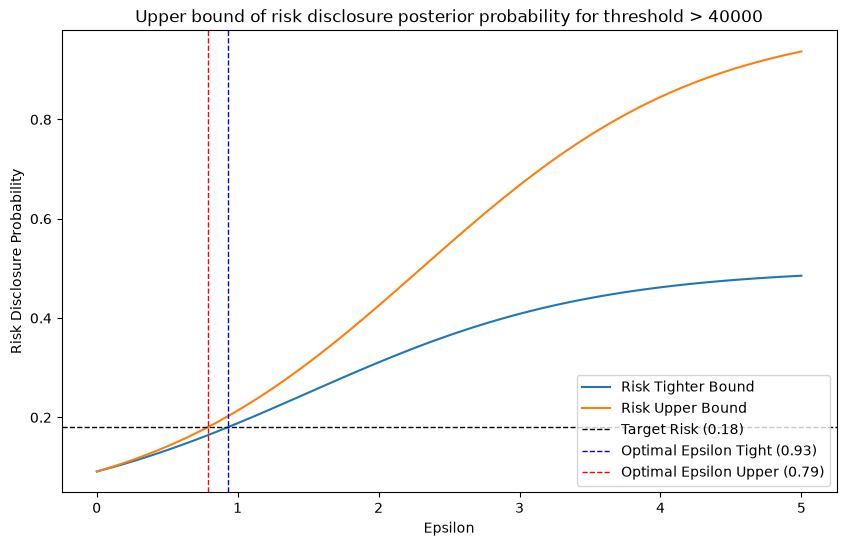

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(epsilon_range, risk_tighter, label='Risk Tighter Bound')
plt.plot(epsilon_range, risk, label='Risk Upper Bound')

# privacy line
plt.axhline(y=target_risk, color='black', linestyle='dashed', linewidth=1, label=f'Target Risk ({target_risk})')

# optimal epsilon line
plt.axvline(x=optimal_epsilon, color='blue', linestyle='dashed', linewidth=1, label=f'Optimal Epsilon Tight ({optimal_epsilon:.2f})')

# epsilon for upper bound line, can be derived from upper bound formula
optimal_epsilon_upper = np.log(((total_people - 1) * target_risk) / (1 - target_risk))
plt.axvline(x=optimal_epsilon_upper, color='red', linestyle='dashed', linewidth=1, label=f'Optimal Epsilon Upper ({optimal_epsilon_upper:.2f})')

plt.xlabel('Epsilon')
plt.ylabel('Risk Disclosure Probability')
plt.title(f'Upper bound of risk disclosure posterior probability for threshold > {threshold}')
plt.legend()
plt.show()